In [3]:
# ==================
# Imports and Setup
# ==================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error

In [4]:
# --------------
# Load the Data
# --------------

df = pd.read_csv("essay_predictions.csv")

print(df.shape)
df.head()

(4946, 9)


,word_count,sentence_count,avg_sentence_length,vocab_richness,readability,topic,semantic_cluster,actual_score,predicted_score
0,453,21,21.571429,0.432671,9.806522,0,1,3,3.633151
1,319,12,26.583333,0.476489,8.833926,4,5,2,2.697008
2,265,14,18.928571,0.667925,7.522960,7,6,2,2.305010
3,544,35,15.542857,0.533088,8.105290,9,1,3,3.856664
4,197,7,28.142857,0.538071,11.732057,1,5,2,1.901057


In [5]:
# ------------------
# Error Metrics
# ------------------

df["error"] = df["predicted_score"] - df["actual_score"]
df["absolute_error"] = abs(df["error"])

In [6]:
# ---------------------
# Hardest Essay Grades
# ---------------------

df.sort_values("absolute_error", ascending=False).head(10)

,word_count,sentence_count,avg_sentence_length,vocab_richness,readability,topic,semantic_cluster,actual_score,predicted_score,error,absolute_error
61,982,36,27.277778,0.429735,12.375828,2,3,2,5.478393,3.478393,3.478393
4298,532,32,16.625000,0.511278,10.297315,2,3,1,4.206460,3.206460,3.206460
1563,737,37,19.918919,0.534600,10.262222,9,1,1,4.107123,3.107123,3.107123
1092,600,38,15.789474,0.545000,7.469333,9,1,1,3.825022,2.825022,2.825022
2640,489,24,20.375000,0.480573,11.564430,2,3,1,3.808025,2.808025,2.808025
3417,522,28,18.642857,0.480843,7.368837,6,6,1,3.801275,2.801275,2.801275
3453,456,25,18.240000,0.572368,9.430618,5,1,1,3.747948,2.747948,2.747948
2544,441,23,19.173913,0.537415,8.897098,4,5,1,3.737970,2.737970,2.737970
2828,483,26,18.576923,0.490683,11.571403,2,3,1,3.735251,2.735251,2.735251
1172,699,35,19.971429,0.480687,9.793408,2,3,2,4.688239,2.688239,2.688239


In [7]:
# ----------------------
# Average Error Metric
# ----------------------

rmse = np.sqrt(mean_squared_error(
    df["actual_score"],
    df["predicted_score"]
))

mae = df["absolute_error"].mean()

print("RMSE:", rmse)
print("Mean Absolute Error:", mae)

RMSE: 0.6740125118410714
Mean Absolute Error: 0.5106770121707843


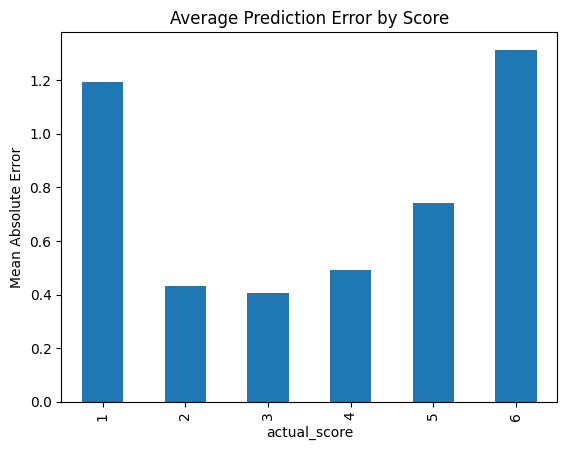

In [8]:
# =======================
# Where AI Performs Best
# =======================

# Group by Score
score_error = df.groupby("actual_score")["absolute_error"].mean()

score_error

# Visualization
score_error.plot(kind="bar")

plt.title("Average Prediction Error by Score")
plt.ylabel("Mean Absolute Error")

plt.show()

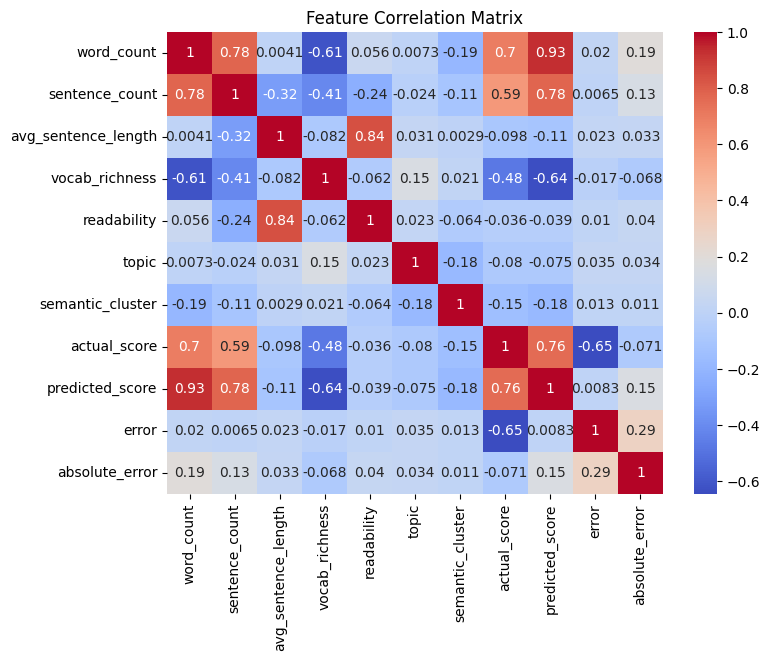

In [10]:
# ======================
# AI Prediction Drivers
# ======================

corr = df.corr(numeric_only=True)

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=True
)

plt.title("Feature Correlation Matrix")

plt.show()

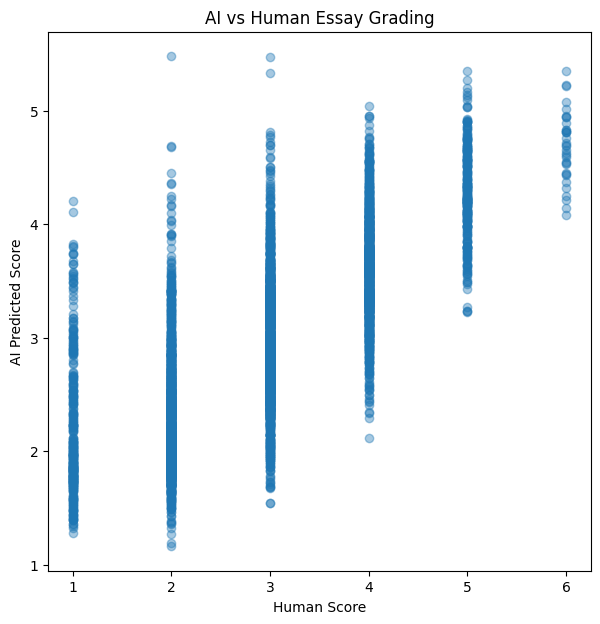

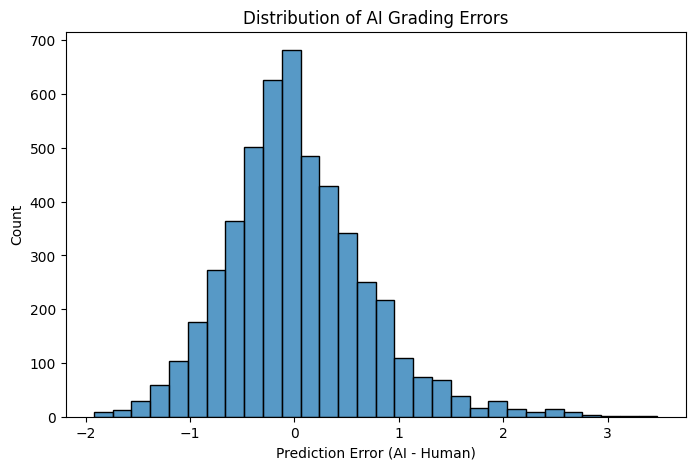

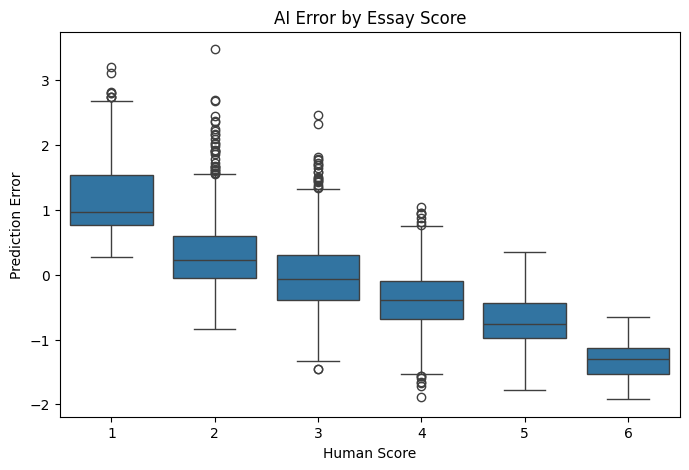

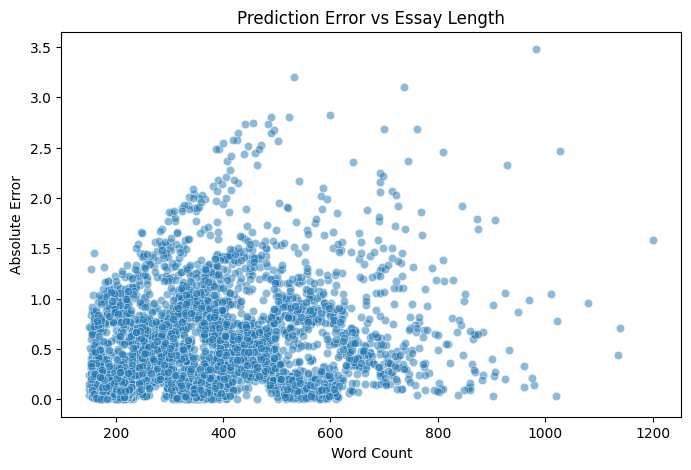

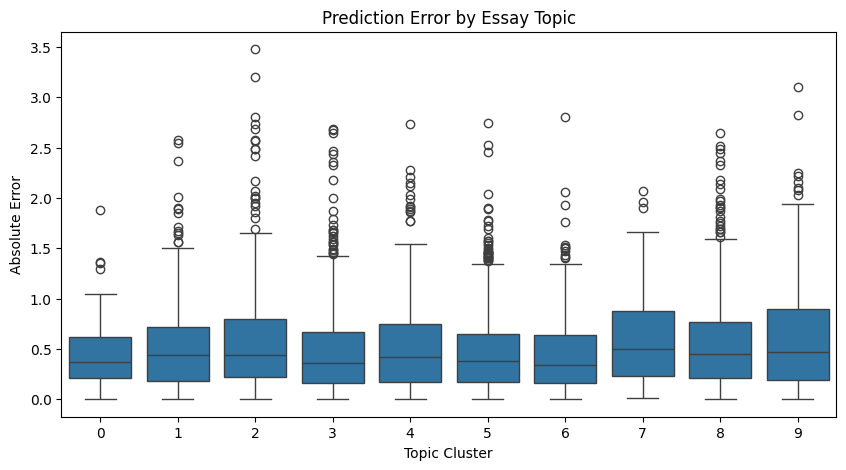

In [12]:
# ====================
# Visualizations
# ====================

# AI vs. Human Scores
plt.figure(figsize=(7,7))

plt.scatter(
    df["actual_score"],
    df["predicted_score"],
    alpha=0.4
)

plt.xlabel("Human Score")
plt.ylabel("AI Predicted Score")
plt.title("AI vs Human Essay Grading")

plt.show()

# Error Distribution
plt.figure(figsize=(8,5))

sns.histplot(df["error"], bins=30)

plt.title("Distribution of AI Grading Errors")
plt.xlabel("Prediction Error (AI - Human)")

plt.show()

# Error vs. Essay Score
plt.figure(figsize=(8,5))

sns.boxplot(
    x="actual_score",
    y="error",
    data=df
)

plt.title("AI Error by Essay Score")
plt.xlabel("Human Score")
plt.ylabel("Prediction Error")

plt.show()

# Error vs. Essay Length
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="word_count",
    y="absolute_error",
    data=df,
    alpha=0.5
)

plt.title("Prediction Error vs Essay Length")
plt.xlabel("Word Count")
plt.ylabel("Absolute Error")

plt.show()

# Error vs. Essay Topic
plt.figure(figsize=(10,5))

sns.boxplot(
    x="topic",
    y="absolute_error",
    data=df
)

plt.title("Prediction Error by Essay Topic")
plt.xlabel("Topic Cluster")
plt.ylabel("Absolute Error")

plt.show()

